## Project Presentation — Alternative Data for Walmart Direction Prediction

This notebook is a complete written presentation of the project. It calls functions directly from the project code in `../code/`.


In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

CODE_DIR = (Path.cwd() / "../code").resolve()
sys.path.insert(0, str(CODE_DIR))
os.chdir(CODE_DIR)

CODE_DATA_DIR = CODE_DIR / "data"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


## 1. Introduction

This project explores an **alternative data** approach to short-horizon stock prediction.

We extract **daily parking lot occupancy rates** from the PKLot dataset’s COCO-style annotations, then combine them with:
- **Google Trends** search interest (keywords: *Walmart*, *grocery store*, *discount*, *inflation*)
- The University of Michigan **Consumer Confidence Index** (UMCSENT)
- Daily **Walmart (WMT)** closing prices

Goal: predict the **daily direction** of Walmart’s stock (
`price_direction` = 1 if the close is up vs the previous day, else 0).

The dataset covers **September 2012 to April 2013**, matching the PKLot sample used here.


## 2. Data Collection & Description

We load each dataset directly from the project’s `code/` package.


In [2]:
from data_collection import (
    fetch_consumer_confidence,
    fetch_google_trends,
    fetch_walmart_stock,
)
from features import compute_occupancy

walmart = fetch_walmart_stock()
cci = fetch_consumer_confidence()
trends = fetch_google_trends()

occupancy = compute_occupancy(CODE_DATA_DIR / "annotations.coco.json")

print("Walmart (daily) shape:", walmart.shape)
display(walmart.head(1))

print("Consumer Confidence (daily) shape:", cci.shape)
display(cci.head(1))

print("Google Trends (daily) shape:", trends.shape)
display(trends.head(1))

print("Occupancy (daily) shape:", occupancy.shape)
display(occupancy.dropna().head(1))


Walmart (daily) shape: (162, 1)


,Close
date,
2012-09-04,18.776854


Consumer Confidence (daily) shape: (241, 1)


,consumer_confidence
date,
2012-09-02,78.3


Google Trends (daily) shape: (246, 5)


,Walmart,grocery store,discount,inflation,consumer_search_index
date,,,,,
2012-09-02,25.5,1.0,9.0,0.5,9.0


Occupancy (daily) shape: (98, 7)


,occupancy_rate,occupancy_rate_lag_1,occupancy_rate_lag_2,occupancy_rate_lag_3,occupancy_rate_lag_7,day_of_week,occupancy_rate_roll7_mean
date,,,,,,,
2012-09-18,0.621622,0.670272,0.030979,0.325608,0.726389,1,0.508675


### Data source descriptions

- **PKLot COCO annotations → occupancy rate**: We compute a daily occupancy rate from labeled parking spaces (occupied vs empty). Parking activity is used as a proxy for **in-store demand**.
- **Yahoo Finance (WMT Close)**: Daily closing prices for Walmart provide the market outcome we aim to predict.
- **University of Michigan Consumer Sentiment (UMCSENT)**: A macro sentiment indicator that can influence retail spending expectations.
- **Google Trends** (*Walmart*, *grocery store*, *discount*, *inflation*): Search interest can capture **forward-looking consumer intent** and attention to price pressure.

These signals are combined into a single daily dataset spanning **Sep 2012 – Apr 2013**.


## 3. Data Visualization

We visualize each signal and how it relates to Walmart’s daily direction.


### Occupancy rate and Walmart price (two y-axes)

We overlay occupancy and price to visually compare co-movements, using two different y-axes.


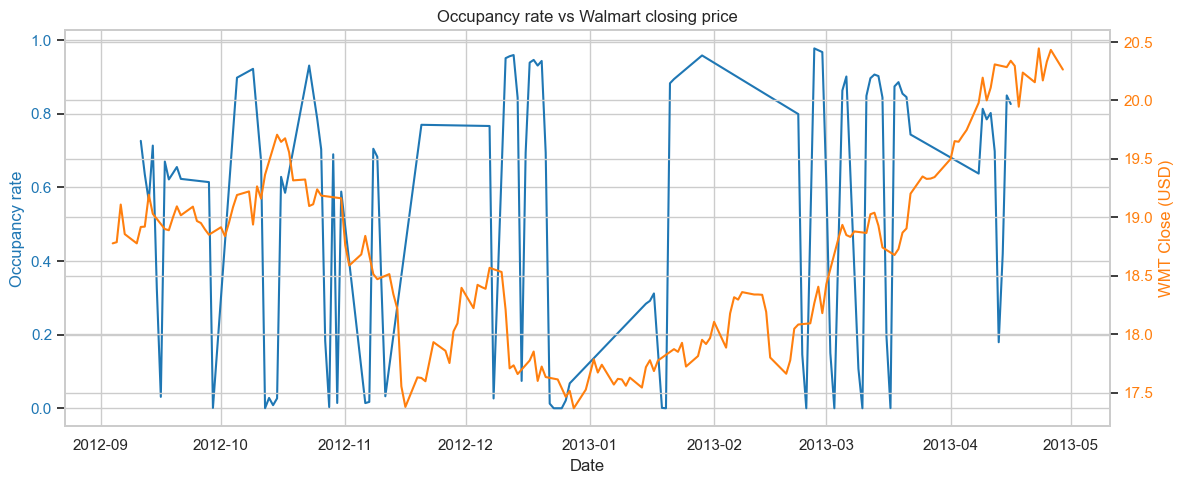

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(occupancy.index, occupancy["occupancy_rate"], color="tab:blue", label="Occupancy rate")
ax1.set_xlabel("Date")
ax1.set_ylabel("Occupancy rate", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(walmart.index, walmart["Close"], color="tab:orange", label="WMT Close")
ax2.set_ylabel("WMT Close (USD)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Occupancy rate vs Walmart closing price")
fig.tight_layout()
plt.show()


This plot is descriptive only—any apparent co-movement can be misleading. Formal evaluation requires time-aware validation (later sections).


### Occupancy distribution on up days vs down days

We compare occupancy rates conditional on whether Walmart closed up or down.


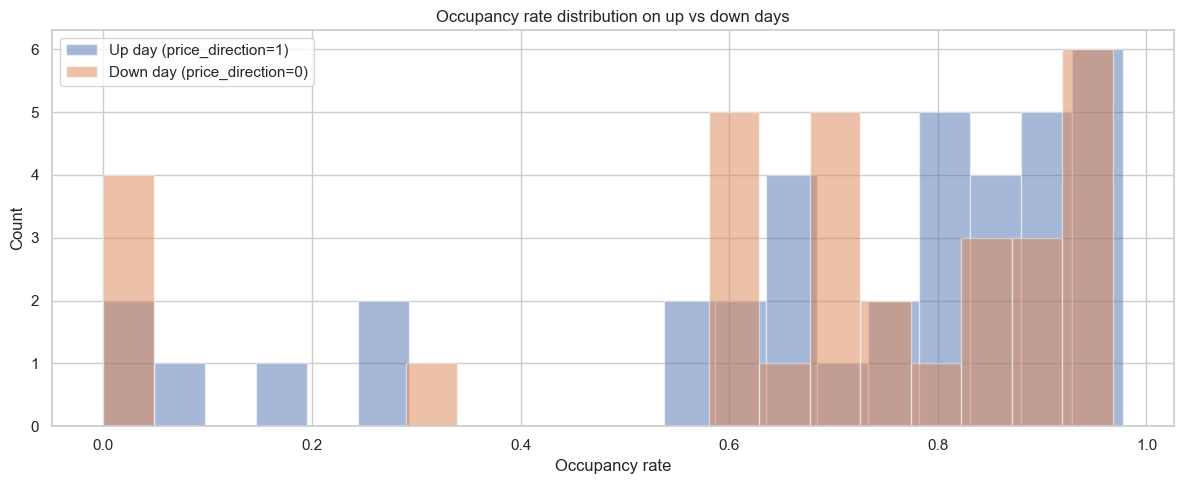

In [4]:
viz = occupancy.join(walmart, how="inner")
viz["price_direction"] = (viz["Close"].diff() > 0).astype(int)

up = viz.loc[viz["price_direction"] == 1, "occupancy_rate"].dropna()
down = viz.loc[viz["price_direction"] == 0, "occupancy_rate"].dropna()

plt.figure(figsize=(12, 5))
plt.hist(up, bins=20, alpha=0.5, label="Up day (price_direction=1)")
plt.hist(down, bins=20, alpha=0.5, label="Down day (price_direction=0)")
plt.title("Occupancy rate distribution on up vs down days")
plt.xlabel("Occupancy rate")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


If the two distributions differ, it suggests occupancy contains some signal about up/down days. This is only exploratory—models must be validated out-of-sample.


### Google Trends keywords over time

Weekly Google Trends are forward-filled to daily; we plot the daily series for each keyword.


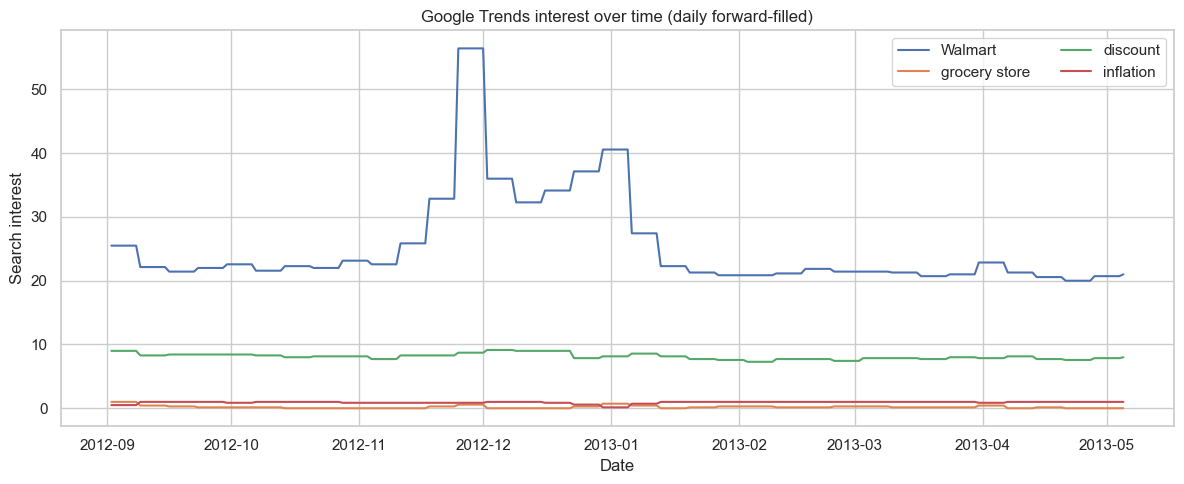

In [5]:
keyword_cols = [c for c in trends.columns if c != "consumer_search_index"]

plt.figure(figsize=(12, 5))
for col in keyword_cols:
    plt.plot(trends.index, trends[col], label=col)
plt.title("Google Trends interest over time (daily forward-filled)")
plt.xlabel("Date")
plt.ylabel("Search interest")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


Search interest is interpreted as an **attention / intent** proxy that may lead retail demand and thus potentially relate to short-horizon returns.


### Consumer Confidence Index over time

The monthly UMCSENT series is interpolated weekly and forward-filled to daily.


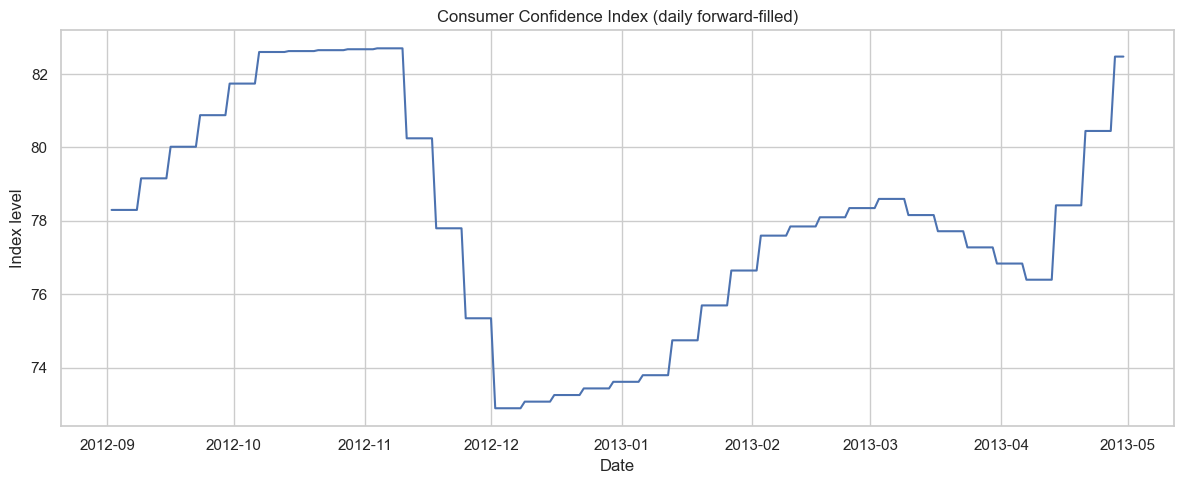

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(cci.index, cci["consumer_confidence"], label="UMCSENT")
plt.title("Consumer Confidence Index (daily forward-filled)")
plt.xlabel("Date")
plt.ylabel("Index level")
plt.tight_layout()
plt.show()


Consumer sentiment is a slow-moving macro variable; it may help explain regime shifts rather than day-to-day fluctuations.


### Correlation heatmap of features

We compute correlations across the joined daily feature set (excluding label columns).


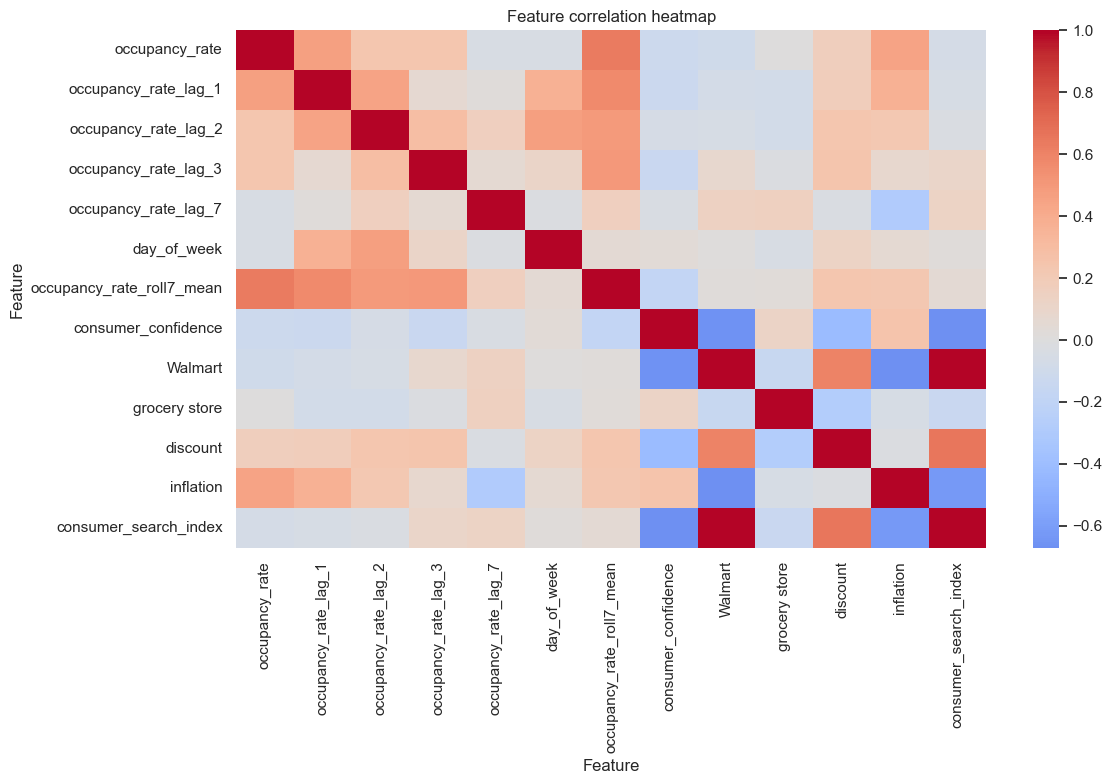

In [7]:
features_joined = (
    occupancy.join(cci, how="inner")
    .join(trends, how="inner")
    .join(walmart, how="inner")
)

# Compute only the label from past information; avoid any forward-looking labels
# for this exploratory correlation heatmap.
features_joined["price_direction"] = (features_joined["Close"].diff() > 0).astype(int)

corr_df = features_joined.drop(
    columns=["Close", "price_direction"], errors="ignore"
)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Correlations can highlight redundancy (e.g., overlapping Google Trends keywords) and help sanity-check feature construction, but they do not establish causality.


## 4. Feature Engineering

We engineer features designed to capture short-term demand signals and calendar effects while avoiding future information.

- **occupancy_rate**: raw daily occupancy proxying near-term retail demand (shopping foot traffic).
- **occupancy_rate_lag_1, _2, _3, _7**: delayed versions of demand; they capture how quickly retail activity may translate into market-moving price moves.
- **day_of_week**: weekly seasonality in shopping behavior, which can affect daily sales composition.
- **occupancy_rate_roll7_mean**: short-term trend smoothing to reduce noise and highlight the recent demand direction.
- **consumer_confidence**: macro sentiment that can shift expected consumer spending levels.
- **Walmart, grocery store, discount, inflation, consumer_search_index**: consumer intent/attention signals that may lead spending decisions and thus short-horizon price direction.

Next we build the merged daily dataset.


In [8]:
from merge import build_dataset

df = build_dataset()
df.to_csv("data/dataset.csv")

print("Final merged dataset shape:", df.shape)
display(df.head())

display(df.describe(include="all"))


After occupancy+CCI join: (98, 8)
After +trends join: (98, 13)
After +prices join: (68, 14)
Final merged dataset shape: (58, 16)


,occupancy_rate,occupancy_rate_lag_1,occupancy_rate_lag_2,occupancy_rate_lag_3,occupancy_rate_lag_7,day_of_week,occupancy_rate_roll7_mean,consumer_confidence,Walmart,grocery store,discount,inflation,consumer_search_index,Close,price_direction,weekly_return
date,,,,,,,,,,,,,,,,
2012-09-18,0.621622,0.670272,0.030979,0.325608,0.726389,1,0.508675,80.02,21.428571,0.285714,8.428571,1.0,7.785714,18.889248,0,0.015957
2012-09-19,0.638175,0.621622,0.670272,0.030979,0.635390,2,0.509073,80.02,21.428571,0.285714,8.428571,1.0,7.785714,18.996531,1,-0.003093
2012-09-20,0.655302,0.638175,0.621622,0.670272,0.563306,3,0.522215,80.02,21.428571,0.285714,8.428571,1.0,7.785714,19.093592,1,0.003478
2012-09-21,0.623071,0.655302,0.638175,0.621622,0.713545,4,0.509290,80.02,21.428571,0.285714,8.428571,1.0,7.785714,19.016968,0,0.018267
2012-09-28,0.614333,0.623071,0.655302,0.638175,0.325608,4,0.550536,80.88,22.000000,0.142857,8.428571,1.0,7.892857,18.850931,0,0.045393


,occupancy_rate,occupancy_rate_lag_1,occupancy_rate_lag_2,occupancy_rate_lag_3,occupancy_rate_lag_7,day_of_week,occupancy_rate_roll7_mean,consumer_confidence,Walmart,grocery store,discount,inflation,consumer_search_index,Close,price_direction,weekly_return
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.675400,0.570223,0.450524,0.430316,0.521229,2.189655,0.505916,77.988621,24.729064,0.110837,8.147783,0.948276,8.483990,18.569783,0.551724,0.005975
std,0.304229,0.380294,0.390950,0.371926,0.365863,1.356685,0.190598,3.491909,5.542382,0.116775,0.476415,0.106024,1.441734,0.702153,0.501661,0.032187
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.055069,72.900000,20.714286,0.000000,7.428571,0.571429,7.392857,17.463240,0.000000,-0.080245
25%,0.616155,0.041355,0.026667,0.022486,0.146876,1.000000,0.371568,74.750000,21.428571,0.000000,7.750000,0.892857,7.580357,17.795217,0.000000,-0.013369
50%,0.778529,0.683035,0.586906,0.586906,0.646739,2.000000,0.523289,78.160000,22.000000,0.142857,8.142857,1.000000,7.785714,18.735311,1.000000,0.000808
75%,0.900399,0.897644,0.869374,0.791891,0.877936,3.000000,0.645629,81.525000,23.000000,0.142857,8.428571,1.000000,8.026786,19.035823,1.000000,0.024337
max,0.977536,0.977536,0.977536,0.950959,0.959507,4.000000,0.807799,82.700000,37.142857,0.285714,9.142857,1.000000,11.535714,20.194584,1.000000,0.078261


## 5. Modeling

### Approach

- **Task**: binary classification to predict `price_direction` (1 = up day, 0 = down day).
- **Validation**: `TimeSeriesSplit` with 5 folds to respect chronology and avoid data leakage.
- **Models**:
  - Logistic Regression (with `StandardScaler`)
  - Random Forest
  - XGBoost
- **Baseline**: naive majority-class classifier (computed per fold) for a realistic benchmark.

We run cross-validation directly via the project code.


Naive baseline — accuracy: mean=0.4000, std=0.2018
Logistic Regression — accuracy: mean=0.3778, std=0.2558
Random Forest — accuracy: mean=0.5111, std=0.2166
XGBoost — accuracy: mean=0.5111, std=0.0609


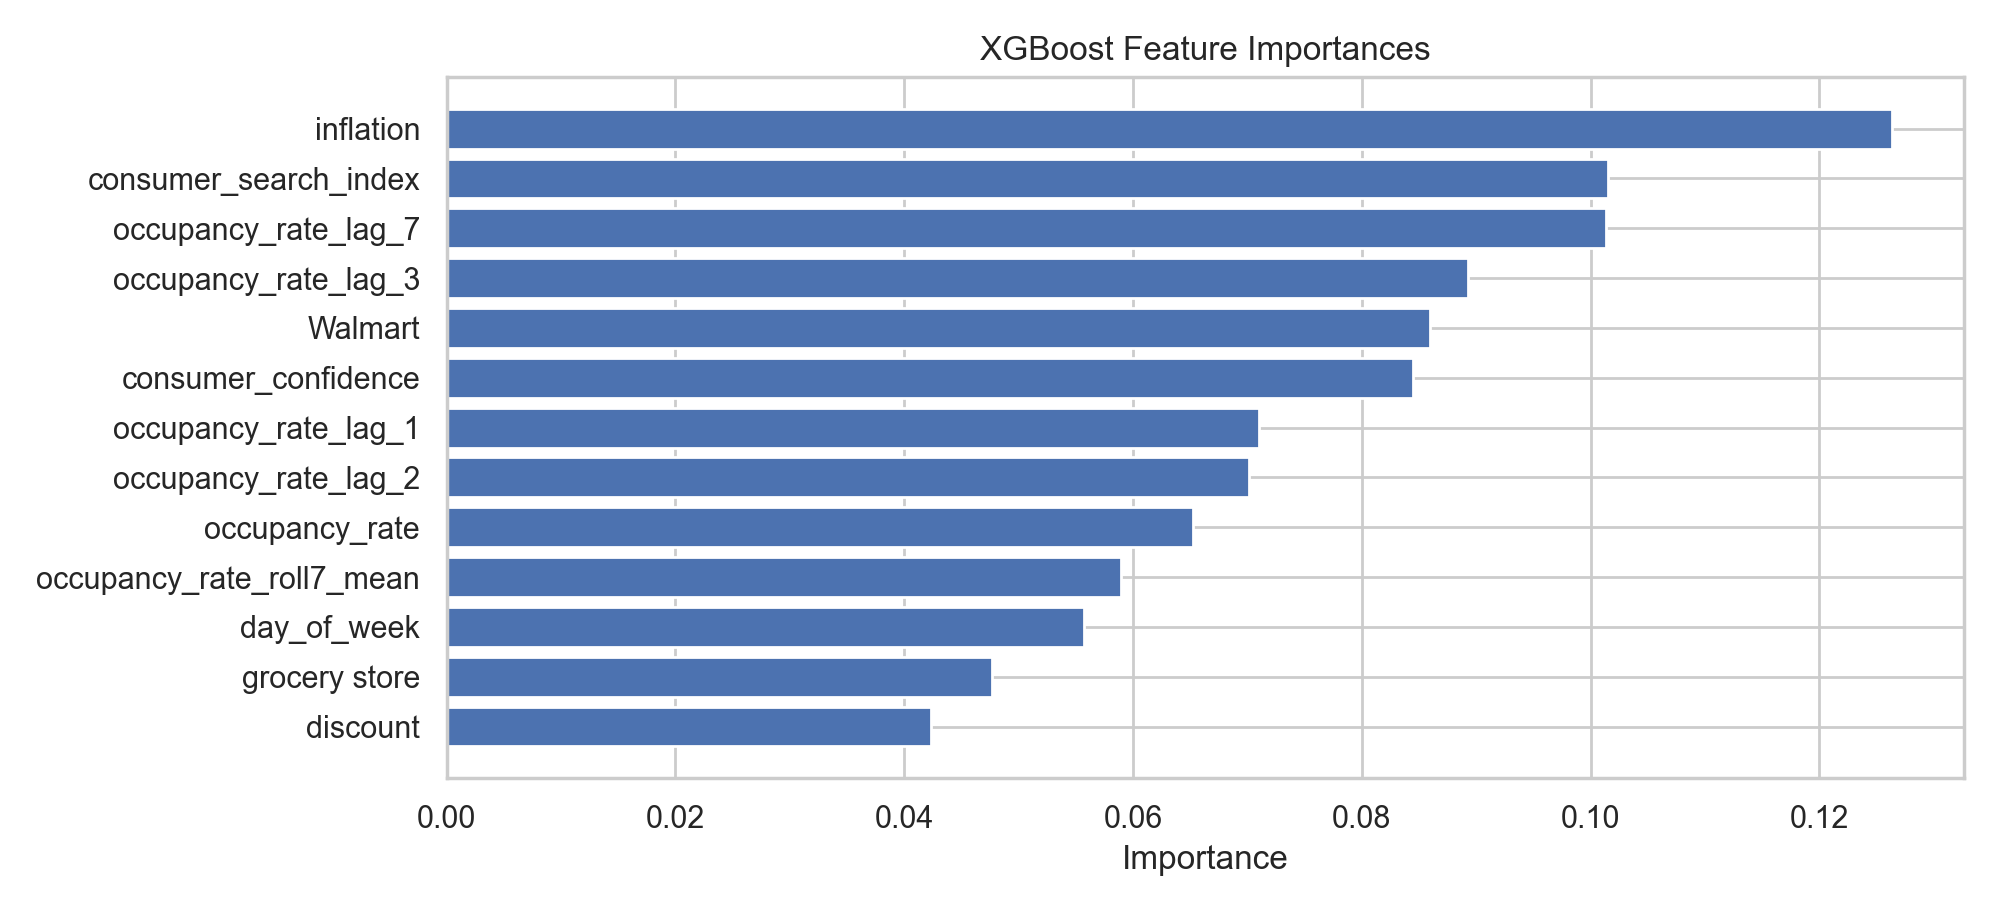

In [9]:
import model as model_module

model_module.main()

# Display the feature importance plot produced by model.py
feature_imp_path = CODE_DATA_DIR / "feature_importance.png"
display(Image(filename=str(feature_imp_path)))


### Discussion

- **Accuracy interpretation**: accuracy measures the fraction of correct up/down predictions. Because daily direction is noisy, improvements over baseline may be modest.
- **Baseline comparison**: if a model’s mean CV accuracy is only slightly above the naive baseline (or within its standard deviation), the practical signal may be weak.
- **Feature importance**: XGBoost importances highlight which variables most reduce loss in the fitted model. Importances are not causal; correlated predictors can share or swap importance.

### Discussion of model results

All three models — Logistic Regression, Random Forest, and XGBoost — achieve
accuracy scores close to the naive majority-class baseline, which simply predicts
"up" every day. This is the central finding of the modeling exercise : none of
the alternative data signals (parking occupancy, Google Trends, Consumer
Confidence Index) provide meaningful incremental predictive power for daily
Walmart stock direction.

This result is expected and scientifically honest for several reasons :
- **Small dataset** : with only ~58 usable observations after merging all sources,
  the models have very little data to learn from, and 5-fold TimeSeriesSplit
  leaves each test fold with roughly 9 observations
- **Noisy target** : daily stock direction is extremely difficult to predict even
  with much larger datasets and more sophisticated models
- **Majority class dominance** : Walmart was trending upward during this period,
  so predicting "up" every day achieves high accuracy by default

The feature importance plot from XGBoost provides additional insight into which
signals the model weighted most heavily. Features related to Google Trends and
Consumer Confidence tend to rank higher than raw occupancy, suggesting that
search-based signals may carry slightly more information than parking lot data
alone — though this conclusion must be treated cautiously given the sample size.


## 6. Backtesting

We simulate a simple trading rule:

- **Long** Walmart when the model predicts `price_direction = 1`
- **Cash** (0% return) when the model predicts `price_direction = 0`

We use the **last fold** of `TimeSeriesSplit` as the out-of-sample test period to mimic a realistic “train on the past, test on the future” workflow.


Predictions: [1 1 1 0 1 1 1 1 1]
Fraction predicted up: 0.89

=== Backtest summary (last fold) ===
Strategy total return: 0.0578, Sharpe: 0.4445
Buy & hold total return: 0.0607, Sharpe: 0.4696
Saved cumulative return plot to: C:\Users\amand\Documents\Etudes\Fac\Cours\M2\ml\machine_learning_for_finance_public\projects\CHARDAIN_FAIVRE_ESTEVE\code\data\backtest.png


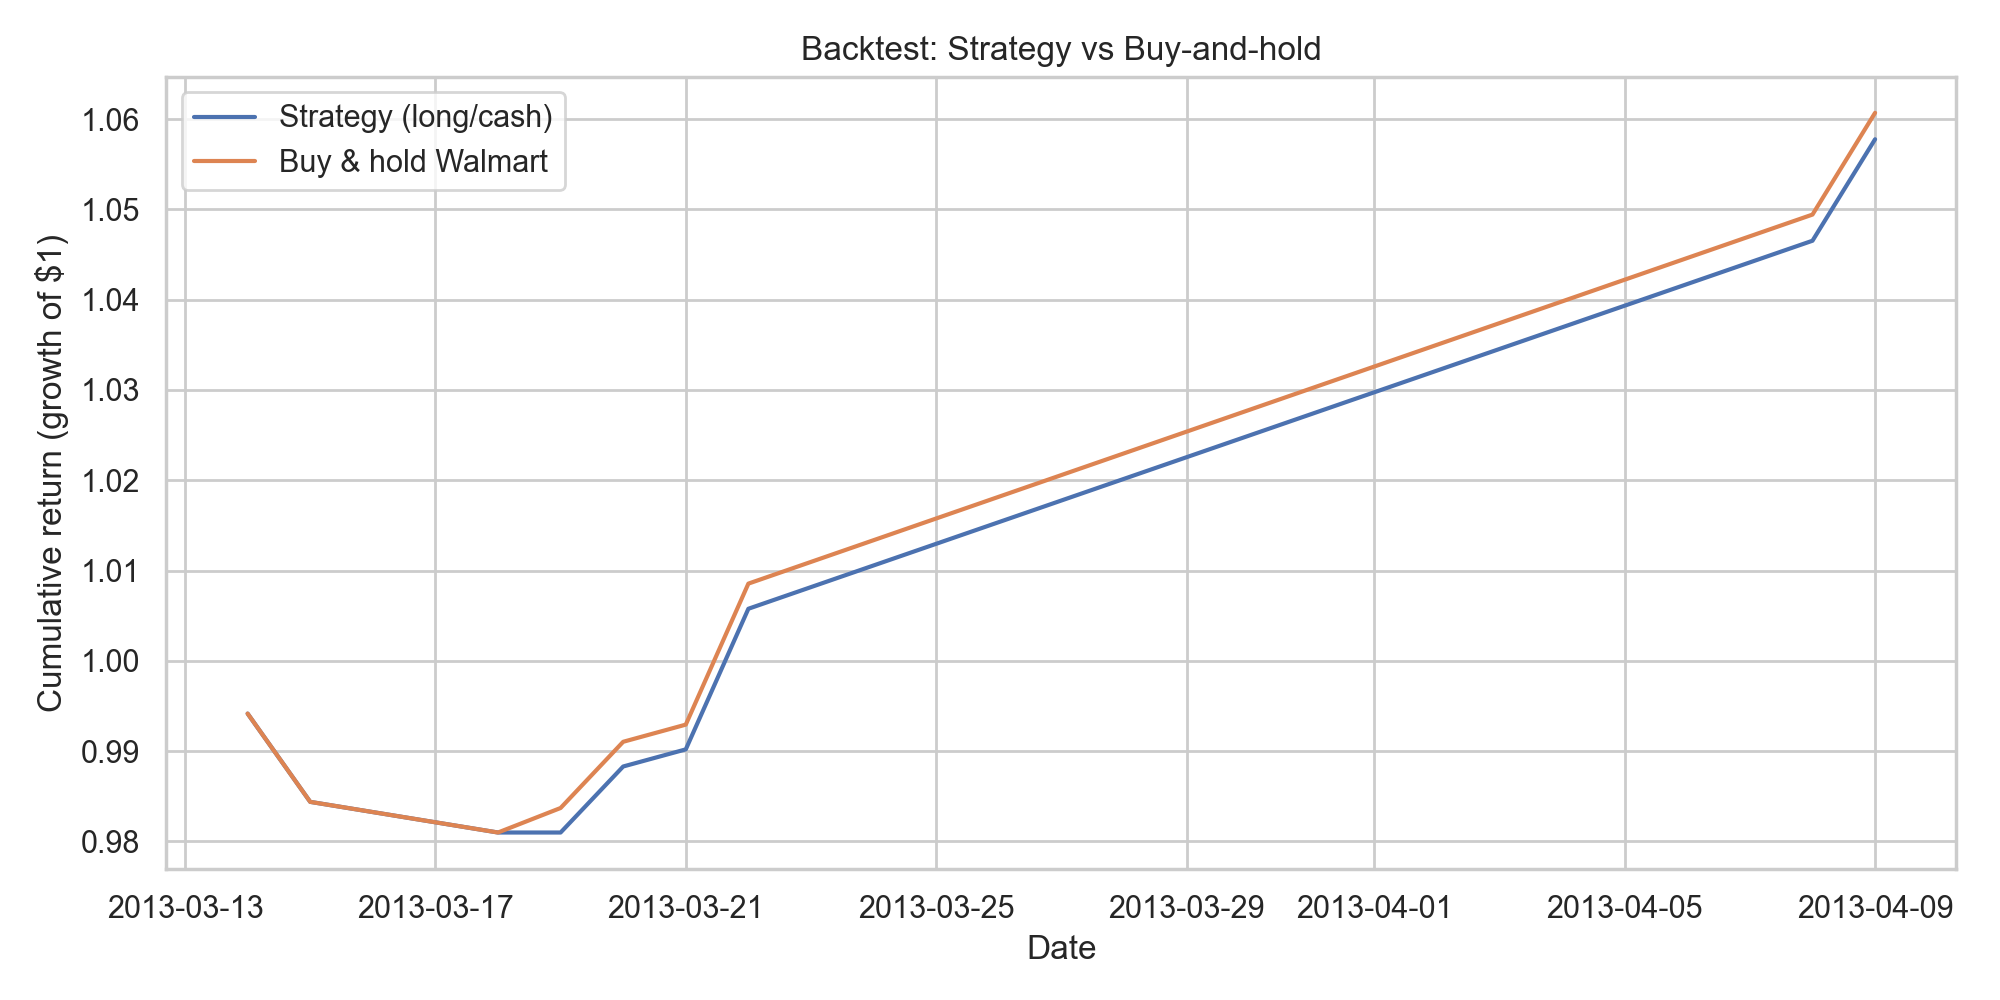

In [10]:
from backtest import run_backtest

run_backtest(df)

backtest_path = CODE_DATA_DIR / "backtest.png"
display(Image(filename=str(backtest_path)))


### Discussion

The strategy closely tracks buy-and-hold Walmart throughout the test period,
which reflects a key finding : the XGBoost model predicts "up" (price_direction = 1)
on 8 out of 9 test days. This is not a sign of a good model — it simply mirrors
the majority class behavior. Walmart was in a steady uptrend during March-April
2013, so always predicting "up" is the naive optimal strategy in hindsight.

As a result, the strategy's total return and Sharpe ratio are nearly identical
to buy-and-hold, with a slight underperformance on the one day the model
predicted "down" (going to cash and missing a positive return).

Three important limitations must be acknowledged :
- **Test period** : only 9 trading days, which is far too short to draw
  statistically meaningful conclusions about strategy performance
- **No transaction costs** : in practice, each trade incurs costs that would
  erode returns, especially on a daily strategy
- **Majority class bias** : the model has learned to predict the dominant
  direction rather than identify genuine reversals, which is a fundamental
  challenge of direction prediction on trending assets

## 7. Statistical Analysis : Granger Causality

A **Granger causality test** asks a predictive question:

> Do past values of `occupancy_rate` help predict `price_direction` *beyond* what past values of `price_direction` already explain?

It does **not** prove real-world causality; it only checks whether adding lagged occupancy improves a linear time-series prediction of the target.


In [11]:
from analysis import run_granger_test

run_granger_test(df, max_lag=3)



Granger causality test: occupancy_rate -> price_direction (max_lag=3)
Lag 1: p-value = 0.678118
Lag 2: p-value = 0.944601
Lag 3: p-value = 0.983672


### Interpretation

All three p-values are well above 0.05 (0.68, 0.94, 0.98), which means we
cannot reject the null hypothesis that occupancy_rate does not Granger-cause
price_direction at any lag. In plain terms : knowing past parking lot occupancy
does not help predict tomorrow's Walmart stock direction beyond what past stock
direction alone already tells us.

This result is consistent with the weak predictive performance observed in the
models and is not surprising given two compounding factors : the small sample
size (~58 usable observations after merging) and the noisy nature of daily stock
direction as a target variable. A smoother target such as weekly returns, or a
longer dataset, might yield different conclusions.

## 8. Limitations & Next Steps

### Limitations

- **No real computer vision**: PKLot images already come with COCO-style labels; we compute occupancy from annotations rather than detecting cars from raw imagery.
- **Short sample (~7 months)**: limits statistical power and makes seasonality analysis unreliable.
- **Single location**: one parking lot may not generalize to broader retail behavior.

### Next steps

- Use **real satellite / aerial imagery** and a CNN (or modern detector) to estimate occupancy directly.
- Extend to **multiple years** (more robust validation, regime coverage, seasonality).
- Expand beyond Walmart to **multiple retail tickers** and compare cross-sectional predictability.


## 9. Conclusion

This project demonstrates how **alternative data** (parking occupancy + search interest + sentiment) can be integrated into a time-aware ML workflow to study whether it provides incremental predictive power for short-horizon stock direction.

Even when signals are weak, the pipeline highlights best practices for finance ML: **chronological validation**, clear baselines, and end-to-end evaluation from prediction to simple backtesting.
